# Chapter 6.9: HSTU & Unified Generative Recommendation

**This is a flagship chapter covering the paradigm shift in recommendation systems.**

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand** the HSTU (Hierarchical Sequential Transduction Unit) architecture from Meta
2. **Implement** the actions-as-tokens paradigm where clicks, likes, and purchases form a vocabulary
3. **Build** a simplified HSTU model with causal attention and next-action prediction
4. **Explain** how HSTU unifies retrieval and ranking in a single generative model
5. **Describe** ItemSage's multi-task item embeddings that feed into HSTU
6. **Compare** the discriminative (CTR) vs generative (HSTU-style) paradigm
7. **Analyze** GR4Rec and RECFORMER as related generative retrieval frameworks

## Prerequisites

- Understanding of transformer architectures and attention mechanisms
- Knowledge of sequential recommendation (SASRec, BERT4Rec)
- Chapters 6.1-6.4 for context on generative approaches
- Familiarity with retrieval and ranking pipelines (Part 2)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part6/chapter_6.9_hstu_unified.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part6/chapter_6.9_hstu_unified.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import math
from collections import defaultdict

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. The Paradigm Shift: From Discriminative to Generative Recommendation

### Traditional Pipeline (Discriminative)

```
Item Pool (millions) -> Retrieval (ANN) -> Candidate Set (hundreds)
  -> Pre-ranking (lightweight) -> Ranking (heavy CTR model) -> Re-ranking -> Display
```

Each stage is a separate model with its own training pipeline, features, and objectives.

### HSTU Pipeline (Generative)

```
User Action Sequence -> HSTU (single model) -> Next Action Prediction -> Display
```

**One model to rule them all.** HSTU unifies retrieval, ranking, and even multi-task objectives into a single generative model.

### "Actions Speak Louder than Words" (Zhai et al., 2024, Meta)

This is arguably **the most important paper in recommendation systems in 2024**. Key claims:

1. User actions (clicks, likes, shares, purchases) are the primary signal
2. A generative model trained on action sequences outperforms complex discriminative pipelines
3. The same architecture scales from retrieval to ranking
4. **1.5 trillion parameters** deployed at Meta scale

> **💡 Concept:** HSTU treats recommendation like language modeling. Just as GPT predicts the next word, HSTU predicts the next user action. The "language" is not text — it's a sequence of (item, action_type, timestamp) tuples.

## 2. Actions as Tokens: The HSTU Vocabulary

In HSTU, the vocabulary consists of:

| Token Type | Examples | Encoding |
|-----------|---------|----------|
| **Item tokens** | item_123, item_456 | Item embedding |
| **Action tokens** | click, like, share, purchase, dwell_long, dwell_short | Action embedding |
| **Time tokens** | time_bucket_0, ..., time_bucket_T | Temporal embedding |
| **Context tokens** | device_mobile, location_US | Context embedding |

A user's history becomes a sequence:

```
[item_42, click, t_1] -> [item_17, like, t_2] -> [item_88, purchase, t_3] -> ???
```

The model predicts: **What is the next (item, action) tuple?**

In [2]:
# Define action vocabulary
ACTION_TYPES = {
    'impression': 0,   # Item was shown
    'click': 1,        # User clicked
    'like': 2,         # User liked/upvoted
    'share': 3,        # User shared
    'purchase': 4,     # User purchased
    'dwell_short': 5,  # Short dwell time (<10s)
    'dwell_long': 6,   # Long dwell time (>30s)
    'skip': 7,         # User skipped
}

# Action value hierarchy (for loss weighting)
ACTION_VALUES = {
    'impression': 0.0,
    'click': 1.0,
    'like': 2.0,
    'share': 3.0,
    'purchase': 5.0,
    'dwell_short': 0.3,
    'dwell_long': 1.5,
    'skip': -0.5,
}

n_action_types = len(ACTION_TYPES)
n_items = 1000
n_users = 500

print(f'Action vocabulary size: {n_action_types}')
print(f'Item vocabulary size: {n_items}')
print(f'Total token space: items({n_items}) + actions({n_action_types}) = {n_items + n_action_types}')

Action vocabulary size: 8
Item vocabulary size: 1000
Total token space: items(1000) + actions(8) = 1008


## 3. Synthetic Action Sequence Data

Let's generate realistic user action sequences that model:
- User preferences (latent factors)
- Action cascades (impression -> click -> like -> purchase)
- Temporal patterns

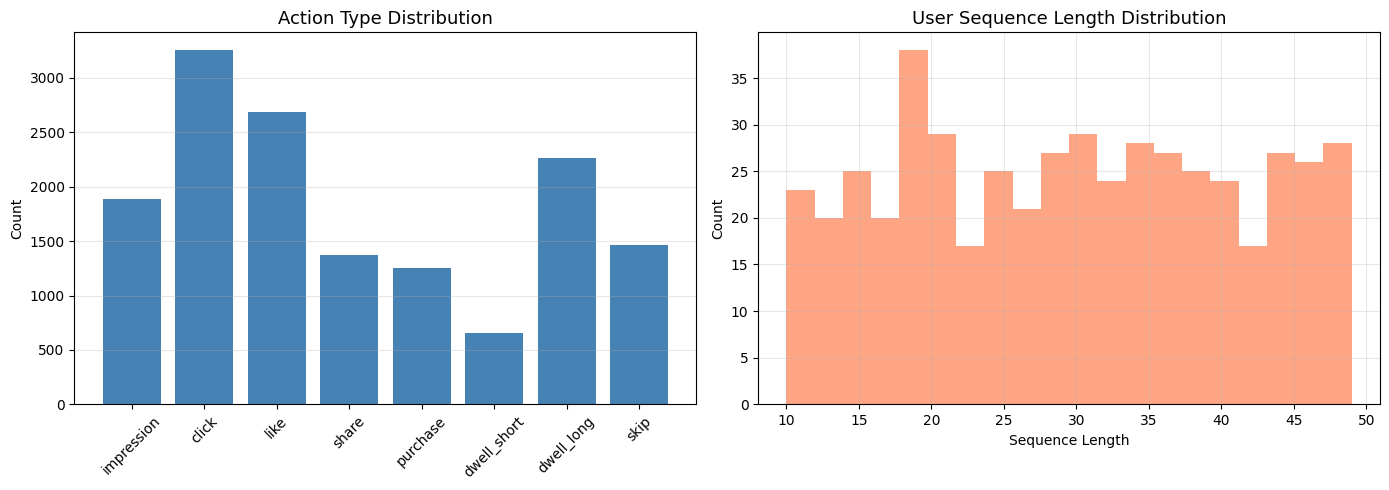

Total sequences: 500
Avg sequence length: 29.7
Action distribution: {'impression': 1887, 'click': 3256, 'like': 2689, 'share': 1372, 'purchase': 1255, 'dwell_short': 655, 'dwell_long': 2260, 'skip': 1461}


In [3]:
def generate_action_sequences(n_users=500, n_items=1000, n_factors=16,
                                max_seq_len=50, seed=42):
    """Generate synthetic user action sequences."""
    rng = np.random.RandomState(seed)
    
    # Latent factors
    user_factors = rng.randn(n_users, n_factors) * 0.5
    item_factors = rng.randn(n_items, n_factors) * 0.5
    item_popularity = rng.power(0.5, n_items)  # Power-law popularity
    
    sequences = []  # List of (user_id, [(item_id, action_type, time_step)])
    
    for u in range(n_users):
        seq_len = rng.randint(10, max_seq_len)
        seq = []
        
        for t in range(seq_len):
            # Sample item (preference + popularity)
            scores = user_factors[u] @ item_factors.T + item_popularity * 2
            scores += rng.randn(n_items) * 0.5
            probs = np.exp(scores - scores.max())
            probs /= probs.sum()
            item_id = rng.choice(n_items, p=probs)
            
            # Determine action based on preference strength
            affinity = user_factors[u] @ item_factors[item_id]
            
            # Action cascade probabilities
            if affinity > 1.0:
                action_probs = [0.05, 0.20, 0.25, 0.15, 0.15, 0.02, 0.15, 0.03]
            elif affinity > 0.0:
                action_probs = [0.15, 0.30, 0.15, 0.05, 0.03, 0.05, 0.20, 0.07]
            else:
                action_probs = [0.30, 0.15, 0.03, 0.01, 0.01, 0.10, 0.05, 0.35]
            
            action_probs = np.array(action_probs)
            action_probs /= action_probs.sum()
            action = rng.choice(n_action_types, p=action_probs)
            
            seq.append((item_id, action, t))
        
        sequences.append((u, seq))
    
    return sequences, user_factors, item_factors


sequences, user_factors, item_factors = generate_action_sequences(n_users, n_items)

# Analyze sequences
all_actions = []
for uid, seq in sequences:
    for item, action, t in seq:
        all_actions.append(action)

action_names = list(ACTION_TYPES.keys())
action_counts = np.bincount(all_actions, minlength=n_action_types)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(action_names, action_counts, color='steelblue')
axes[0].set_title('Action Type Distribution', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

seq_lengths = [len(seq) for _, seq in sequences]
axes[1].hist(seq_lengths, bins=20, color='coral', alpha=0.7)
axes[1].set_xlabel('Sequence Length')
axes[1].set_ylabel('Count')
axes[1].set_title('User Sequence Length Distribution', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Total sequences: {len(sequences)}')
print(f'Avg sequence length: {np.mean(seq_lengths):.1f}')
print(f'Action distribution: {dict(zip(action_names, action_counts))}')

## 4. HSTU Architecture

### Hierarchical Sequential Transduction Unit

HSTU has a hierarchical structure:

1. **Token-level**: Each (item, action, time) tuple is encoded into a single token embedding
2. **Sequence-level**: Causal transformer processes the action sequence
3. **Output-level**: Predicts next item and action type simultaneously

### Key Design Choices

- **Causal attention**: Each position only attends to past positions (autoregressive)
- **Multi-task head**: Simultaneously predicts item and action type
- **Relative time encoding**: Time gaps between actions are encoded relatively
- **Action-aware attention**: Different action types get different attention patterns

### Differences from SASRec

| Feature | SASRec | HSTU |
|---------|--------|------|
| Input | Item IDs only | Item + Action + Time |
| Output | Next item | Next item + action |
| Attention | Standard causal | Action-aware causal |
| Scale | ~1M params | Up to 1.5T params |
| Unified | Ranking only | Retrieval + Ranking |

> **🔑 Pro Tip:** HSTU's power comes from treating ALL user actions as signal, not just clicks. A "skip" is informative — the user saw the item and chose not to engage. This negative signal is lost in traditional click-only models.

In [4]:
class ActionTokenEmbedding(nn.Module):
    """Combines item, action, and time into a single token embedding.
    
    Reference: Zhai et al., "Actions Speak Louder than Words", 2024, Meta.
    """
    
    def __init__(self, n_items, n_actions, embed_dim, max_time_buckets=100):
        super().__init__()
        self.item_embed = nn.Embedding(n_items, embed_dim)
        self.action_embed = nn.Embedding(n_actions, embed_dim)
        self.time_embed = nn.Embedding(max_time_buckets, embed_dim)
        
        # Fusion: combine item + action + time into a single representation
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim * 3, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU()
        )
    
    def forward(self, item_ids, action_ids, time_ids):
        i_emb = self.item_embed(item_ids)
        a_emb = self.action_embed(action_ids)
        t_emb = self.time_embed(time_ids)
        combined = torch.cat([i_emb, a_emb, t_emb], dim=-1)
        return self.fusion(combined)


class ActionAwareAttention(nn.Module):
    """Action-aware multi-head attention.
    
    Different action types create different attention patterns:
    - Purchases get higher attention weight
    - Skips get lower attention weight
    """
    
    def __init__(self, embed_dim, n_heads, n_actions, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = embed_dim // n_heads
        self.scale = self.head_dim ** -0.5
        
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        
        # Action-type attention bias
        self.action_bias = nn.Parameter(torch.zeros(n_actions))
        # Initialize with action values
        with torch.no_grad():
            for action_name, idx in ACTION_TYPES.items():
                self.action_bias[idx] = ACTION_VALUES[action_name] * 0.5
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, action_ids, causal_mask=None):
        B, L, D = x.shape
        
        q = self.q_proj(x).view(B, L, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, L, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, L, self.n_heads, self.head_dim).transpose(1, 2)
        
        # Standard attention
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, H, L, L)
        
        # Add action-type bias to key positions
        action_bias = self.action_bias[action_ids]  # (B, L)
        attn = attn + action_bias.unsqueeze(1).unsqueeze(2)  # Broadcast
        
        # Causal mask
        if causal_mask is not None:
            attn = attn.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0), -1e9)
        
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        
        out = (attn @ v).transpose(1, 2).contiguous().view(B, L, D)
        return self.out_proj(out), attn


class HSTUBlock(nn.Module):
    """A single HSTU transformer block."""
    
    def __init__(self, embed_dim, n_heads, n_actions, ff_dim=None, dropout=0.1):
        super().__init__()
        ff_dim = ff_dim or embed_dim * 4
        
        self.attention = ActionAwareAttention(embed_dim, n_heads, n_actions, dropout)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x, action_ids, causal_mask=None):
        # Pre-norm architecture
        attn_out, attn_weights = self.attention(self.ln1(x), action_ids, causal_mask)
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x, attn_weights


class HSTU(nn.Module):
    """Hierarchical Sequential Transduction Unit.
    
    Simplified implementation of the architecture from:
    Zhai et al., "Actions Speak Louder than Words: Trillion-Parameter
    Sequential Transducers for Generative Recommendations", ICML 2024, Meta.
    """
    
    def __init__(self, n_items, n_actions, embed_dim=64, n_heads=4,
                 n_layers=3, max_seq_len=64, dropout=0.1):
        super().__init__()
        self.n_items = n_items
        self.n_actions = n_actions
        self.embed_dim = embed_dim
        self.max_seq_len = max_seq_len
        
        # Token embedding
        self.token_embed = ActionTokenEmbedding(n_items, n_actions, embed_dim)
        
        # Positional embedding (learnable)
        self.pos_embed = nn.Embedding(max_seq_len, embed_dim)
        self.dropout = nn.Dropout(dropout)
        
        # Transformer blocks
        self.blocks = nn.ModuleList([
            HSTUBlock(embed_dim, n_heads, n_actions, dropout=dropout)
            for _ in range(n_layers)
        ])
        
        self.ln_final = nn.LayerNorm(embed_dim)
        
        # Multi-task output heads
        # Head 1: Next item prediction (retrieval/ranking)
        self.item_head = nn.Linear(embed_dim, n_items, bias=False)
        # Head 2: Next action type prediction
        self.action_head = nn.Linear(embed_dim, n_actions)
    
    def forward(self, item_ids, action_ids, time_ids):
        B, L = item_ids.shape
        
        # Token embeddings
        h = self.token_embed(item_ids, action_ids, time_ids)
        
        # Add positional embedding
        positions = torch.arange(L, device=item_ids.device).unsqueeze(0)
        h = h + self.pos_embed(positions)
        h = self.dropout(h)
        
        # Causal mask
        causal_mask = torch.triu(torch.ones(L, L, device=item_ids.device), diagonal=1).bool()
        
        # Transformer blocks
        all_attn_weights = []
        for block in self.blocks:
            h, attn_w = block(h, action_ids, causal_mask)
            all_attn_weights.append(attn_w)
        
        h = self.ln_final(h)
        
        # Predictions
        item_logits = self.item_head(h)  # (B, L, n_items)
        action_logits = self.action_head(h)  # (B, L, n_actions)
        
        return item_logits, action_logits, all_attn_weights
    
    @torch.no_grad()
    def predict_next(self, item_ids, action_ids, time_ids, top_k=10):
        """Predict next item and action."""
        self.eval()
        item_logits, action_logits, _ = self.forward(item_ids, action_ids, time_ids)
        
        # Use last position
        last_item_logits = item_logits[:, -1, :]  # (B, n_items)
        last_action_logits = action_logits[:, -1, :]  # (B, n_actions)
        
        # Top-K items
        _, top_items = torch.topk(last_item_logits, top_k, dim=-1)
        # Most likely action
        predicted_action = last_action_logits.argmax(dim=-1)
        
        return top_items, predicted_action


# Instantiate HSTU
hstu = HSTU(n_items=n_items, n_actions=n_action_types, embed_dim=64,
            n_heads=4, n_layers=3, max_seq_len=64).to(device)

n_params = sum(p.numel() for p in hstu.parameters())
print(f'HSTU model parameters: {n_params:,}')
print(f'\nArchitecture:')
print(f'  Embedding dim: 64')
print(f'  Attention heads: 4')
print(f'  Transformer layers: 3')
print(f'  Item vocabulary: {n_items}')
print(f'  Action vocabulary: {n_action_types}')

HSTU model parameters: 302,112

Architecture:
  Embedding dim: 64
  Attention heads: 4
  Transformer layers: 3
  Item vocabulary: 1000
  Action vocabulary: 8


## 5. Preparing Training Data

In [5]:
def prepare_hstu_data(sequences, max_seq_len=50):
    """Convert action sequences to training tensors."""
    all_items = []
    all_actions = []
    all_times = []
    all_target_items = []
    all_target_actions = []
    
    for uid, seq in sequences:
        if len(seq) < 3:
            continue
        
        # Truncate to max_seq_len
        seq = seq[-max_seq_len:]
        
        items = [s[0] for s in seq]
        actions = [s[1] for s in seq]
        times = [min(s[2], 99) for s in seq]  # Bucket time
        
        # Input: all but last
        # Target: all but first (shifted by 1)
        pad_len = max_seq_len - len(items)
        
        input_items = items[:-1] + [0] * max(0, pad_len + 1)
        input_actions = actions[:-1] + [0] * max(0, pad_len + 1)
        input_times = times[:-1] + [0] * max(0, pad_len + 1)
        target_items = items[1:] + [0] * max(0, pad_len + 1)
        target_actions = actions[1:] + [0] * max(0, pad_len + 1)
        
        # Truncate to max_seq_len - 1
        L = max_seq_len - 1
        all_items.append(input_items[:L])
        all_actions.append(input_actions[:L])
        all_times.append(input_times[:L])
        all_target_items.append(target_items[:L])
        all_target_actions.append(target_actions[:L])
    
    return (
        torch.LongTensor(all_items),
        torch.LongTensor(all_actions),
        torch.LongTensor(all_times),
        torch.LongTensor(all_target_items),
        torch.LongTensor(all_target_actions)
    )


# Split sequences into train/test
train_seqs = sequences[:400]
test_seqs = sequences[400:]

train_items, train_actions, train_times, train_target_items, train_target_actions = \
    prepare_hstu_data(train_seqs, max_seq_len=40)

test_items, test_actions, test_times, test_target_items, test_target_actions = \
    prepare_hstu_data(test_seqs, max_seq_len=40)

print(f'Training sequences: {len(train_items)}')
print(f'Test sequences: {len(test_items)}')
print(f'Sequence length: {train_items.shape[1]}')

Training sequences: 400
Test sequences: 100
Sequence length: 39


## 6. Training HSTU

HSTU is trained with a multi-task objective:

$$\mathcal{L} = \mathcal{L}_{\text{item}} + \lambda \cdot \mathcal{L}_{\text{action}}$$

where:
- $\mathcal{L}_{\text{item}}$: Cross-entropy for next-item prediction
- $\mathcal{L}_{\text{action}}$: Cross-entropy for next-action prediction
- Actions are weighted by their value (purchases > clicks > skips)

> **⚠️ Common Pitfall:** At Meta scale, HSTU uses sampled softmax over items (computing full softmax over millions of items is intractable). For our demonstration, we use full softmax since our item set is small.

In [6]:
def compute_hstu_loss(item_logits, action_logits, target_items, target_actions,
                       action_weight=0.3):
    """Compute multi-task HSTU training loss."""
    B, L, V = item_logits.shape
    
    # Mask out padding
    mask = (target_items > 0).float()  # (B, L)
    
    # Item prediction loss (cross-entropy)
    item_loss = F.cross_entropy(
        item_logits.view(-1, V),
        target_items.view(-1),
        ignore_index=0,
        reduction='mean'
    )
    
    # Action prediction loss
    action_loss = F.cross_entropy(
        action_logits.view(-1, action_logits.size(-1)),
        target_actions.view(-1),
        ignore_index=0,
        reduction='mean'
    )
    
    total_loss = item_loss + action_weight * action_loss
    return total_loss, item_loss, action_loss


def evaluate_hstu(model, test_items, test_actions, test_times,
                   test_target_items, k=20):
    """Evaluate HSTU: next-item prediction."""
    model.eval()
    with torch.no_grad():
        item_logits, action_logits, _ = model(test_items, test_actions, test_times)
    
    # Evaluate at each non-padded position
    hits_at_k = []
    ndcgs = []
    
    for b in range(len(test_items)):
        for t in range(test_items.shape[1]):
            target = test_target_items[b, t].item()
            if target == 0:  # Padding
                continue
            
            logits = item_logits[b, t]
            _, top_k_items = torch.topk(logits, k)
            top_k_list = top_k_items.tolist()
            
            hit = 1 if target in top_k_list else 0
            hits_at_k.append(hit)
            
            if hit:
                rank = top_k_list.index(target)
                ndcgs.append(1.0 / np.log2(rank + 2))
            else:
                ndcgs.append(0.0)
    
    return np.mean(hits_at_k), np.mean(ndcgs)


# Training loop
hstu = HSTU(n_items=n_items, n_actions=n_action_types, embed_dim=64,
            n_heads=4, n_layers=3, max_seq_len=40).to(device)

optimizer = torch.optim.AdamW(hstu.parameters(), lr=1e-3, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset = TensorDataset(train_items, train_actions, train_times,
                         train_target_items, train_target_actions)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

history = {'total_loss': [], 'item_loss': [], 'action_loss': [], 'hit_rate': [], 'ndcg': []}

for epoch in range(50):
    hstu.train()
    epoch_total = 0
    epoch_item = 0
    epoch_action = 0
    n_batches = 0
    
    for batch in loader:
        b_items, b_actions, b_times, b_t_items, b_t_actions = batch
        
        item_logits, action_logits, _ = hstu(b_items, b_actions, b_times)
        total_loss, item_loss, action_loss = compute_hstu_loss(
            item_logits, action_logits, b_t_items, b_t_actions
        )
        
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(hstu.parameters(), 1.0)
        optimizer.step()
        
        epoch_total += total_loss.item()
        epoch_item += item_loss.item()
        epoch_action += action_loss.item()
        n_batches += 1
    
    scheduler.step()
    
    if (epoch + 1) % 10 == 0:
        hr, ndcg = evaluate_hstu(hstu, test_items, test_actions, test_times,
                                  test_target_items, k=20)
        history['total_loss'].append(epoch_total / n_batches)
        history['item_loss'].append(epoch_item / n_batches)
        history['action_loss'].append(epoch_action / n_batches)
        history['hit_rate'].append(hr)
        history['ndcg'].append(ndcg)
        
        print(f'Epoch {epoch+1:3d} | Loss: {epoch_total/n_batches:.4f} '
              f'(item: {epoch_item/n_batches:.4f}, action: {epoch_action/n_batches:.4f}) | '
              f'HR@20: {hr:.4f} | NDCG@20: {ndcg:.4f}')

Epoch  10 | Loss: 7.0006 (item: 6.4478, action: 1.8427) | HR@20: 0.0559 | NDCG@20: 0.0206


Epoch  20 | Loss: 6.6093 (item: 6.0585, action: 1.8360) | HR@20: 0.0528 | NDCG@20: 0.0196


Epoch  30 | Loss: 6.3402 (item: 5.7931, action: 1.8233) | HR@20: 0.0431 | NDCG@20: 0.0162


Epoch  40 | Loss: 6.1897 (item: 5.6461, action: 1.8121) | HR@20: 0.0437 | NDCG@20: 0.0163


Epoch  50 | Loss: 6.1492 (item: 5.6048, action: 1.8146) | HR@20: 0.0424 | NDCG@20: 0.0160


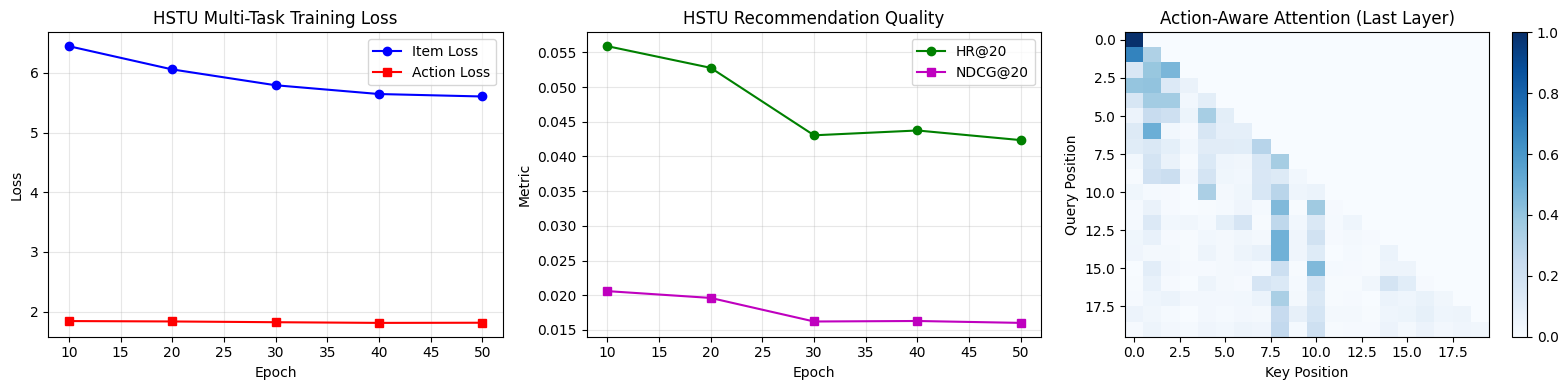

In [7]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

eval_epochs = list(range(10, 51, 10))

axes[0].plot(eval_epochs, history['item_loss'], 'b-o', label='Item Loss', markersize=6)
axes[0].plot(eval_epochs, history['action_loss'], 'r-s', label='Action Loss', markersize=6)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('HSTU Multi-Task Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_epochs, history['hit_rate'], 'g-o', label='HR@20', markersize=6)
axes[1].plot(eval_epochs, history['ndcg'], 'm-s', label='NDCG@20', markersize=6)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Metric')
axes[1].set_title('HSTU Recommendation Quality')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Attention visualization
hstu.eval()
with torch.no_grad():
    _, _, attn_weights = hstu(test_items[:1], test_actions[:1], test_times[:1])

# Show attention from last layer, first head
attn = attn_weights[-1][0, 0, :20, :20].cpu().numpy()
im = axes[2].imshow(attn, cmap='Blues', aspect='auto')
axes[2].set_xlabel('Key Position')
axes[2].set_ylabel('Query Position')
axes[2].set_title('Action-Aware Attention (Last Layer)')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

## 7. ItemSage: Multi-Task Item Embeddings

**ItemSage** (Meta, 2024) provides the item embeddings that feed into HSTU:

- **Multi-modal**: Combines text (title, description), visual (images), and categorical features
- **Multi-task**: Trained on multiple objectives simultaneously (search, recommendation, ads)
- **Graph-enhanced**: Uses item-item co-occurrence graphs

The relationship: ItemSage provides item representations -> HSTU processes sequences of these representations.

> **💡 Concept:** ItemSage ensures that every item has a rich, pre-computed embedding that captures its semantic meaning. This allows HSTU to focus on learning sequential patterns rather than item semantics.

In [8]:
class ItemSageSimplified(nn.Module):
    """Simplified ItemSage: multi-task item encoder.
    
    Reference: Meta, "ItemSage: Multi-Modal & Multi-Task Item Embeddings", 2024.
    """
    
    def __init__(self, n_items, text_dim=32, visual_dim=32, cat_dim=16,
                 embed_dim=64, n_tasks=3):
        super().__init__()
        # Modality encoders
        self.text_encoder = nn.Sequential(
            nn.Linear(text_dim, embed_dim), nn.GELU()
        )
        self.visual_encoder = nn.Sequential(
            nn.Linear(visual_dim, embed_dim), nn.GELU()
        )
        self.cat_encoder = nn.Sequential(
            nn.Linear(cat_dim, embed_dim), nn.GELU()
        )
        
        # Fusion
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim * 3, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU()
        )
        
        # Task-specific heads
        self.task_heads = nn.ModuleList([
            nn.Linear(embed_dim, embed_dim) for _ in range(n_tasks)
        ])
    
    def forward(self, text_feat, visual_feat, cat_feat, task_id=None):
        t = self.text_encoder(text_feat)
        v = self.visual_encoder(visual_feat)
        c = self.cat_encoder(cat_feat)
        
        fused = self.fusion(torch.cat([t, v, c], dim=-1))
        
        if task_id is not None:
            return self.task_heads[task_id](fused)
        return fused  # General embedding


# Demo
item_sage = ItemSageSimplified(n_items)
dummy_text = torch.randn(5, 32)
dummy_visual = torch.randn(5, 32)
dummy_cat = torch.randn(5, 16)

general_emb = item_sage(dummy_text, dummy_visual, dummy_cat)
search_emb = item_sage(dummy_text, dummy_visual, dummy_cat, task_id=0)
rec_emb = item_sage(dummy_text, dummy_visual, dummy_cat, task_id=1)

print(f'General embedding shape: {general_emb.shape}')
print(f'Search-specific embedding shape: {search_emb.shape}')
print(f'Rec-specific embedding shape: {rec_emb.shape}')

General embedding shape: torch.Size([5, 64])
Search-specific embedding shape: torch.Size([5, 64])
Rec-specific embedding shape: torch.Size([5, 64])


## 8. Discriminative vs Generative: The Paradigm Comparison

Let's build a traditional discriminative model and compare with HSTU.

/Users/liuhongxuan/project/rec_system/.venv/lib/python3.11/site-packages/torch/nn/functional.py:5109: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(


SASRec Epoch 10 | HR@20: 0.0507


SASRec Epoch 20 | HR@20: 0.0469


SASRec Epoch 30 | HR@20: 0.0399


SASRec Epoch 40 | HR@20: 0.0424


SASRec Epoch 50 | HR@20: 0.0392


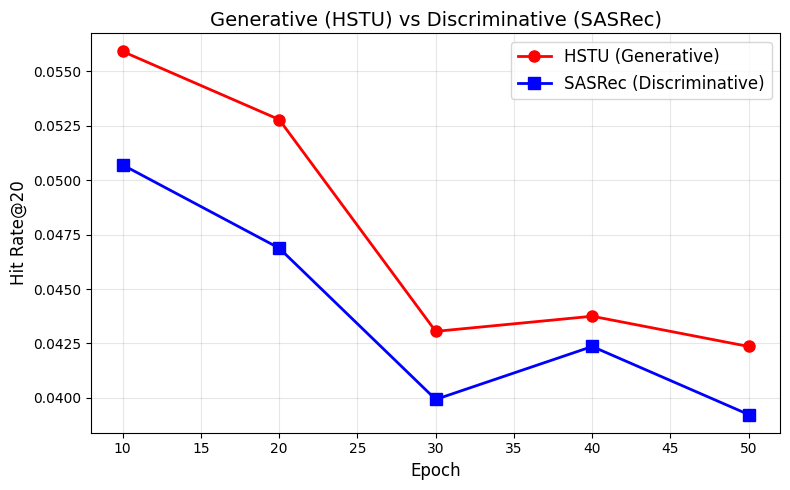


Final HR@20 - HSTU: 0.0424
Final HR@20 - SASRec: 0.0392


In [9]:
class DiscriminativeSASRec(nn.Module):
    """Standard SASRec (item-only, no action modeling)."""
    
    def __init__(self, n_items, embed_dim=64, n_heads=4, n_layers=2, max_seq_len=40):
        super().__init__()
        self.item_embed = nn.Embedding(n_items, embed_dim, padding_idx=0)
        self.pos_embed = nn.Embedding(max_seq_len, embed_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.output = nn.Linear(embed_dim, n_items)
    
    def forward(self, item_ids):
        B, L = item_ids.shape
        positions = torch.arange(L, device=item_ids.device).unsqueeze(0)
        h = self.item_embed(item_ids) + self.pos_embed(positions)
        
        causal_mask = nn.Transformer.generate_square_subsequent_mask(L).to(item_ids.device)
        padding_mask = (item_ids == 0)
        
        h = self.transformer(h, mask=causal_mask, src_key_padding_mask=padding_mask)
        return self.output(h)


# Train SASRec baseline
sasrec = DiscriminativeSASRec(n_items, embed_dim=64, n_heads=4, n_layers=2).to(device)
sasrec_opt = torch.optim.AdamW(sasrec.parameters(), lr=1e-3)

sasrec_dataset = TensorDataset(train_items, train_target_items)
sasrec_loader = DataLoader(sasrec_dataset, batch_size=64, shuffle=True)

sasrec_hr_history = []

for epoch in range(50):
    sasrec.train()
    for b_items, b_targets in sasrec_loader:
        logits = sasrec(b_items)
        loss = F.cross_entropy(logits.view(-1, n_items), b_targets.view(-1), ignore_index=0)
        sasrec_opt.zero_grad()
        loss.backward()
        sasrec_opt.step()
    
    if (epoch + 1) % 10 == 0:
        sasrec.eval()
        with torch.no_grad():
            logits = sasrec(test_items)
            hits = []
            for b in range(len(test_items)):
                for t in range(test_items.shape[1]):
                    target = test_target_items[b, t].item()
                    if target == 0:
                        continue
                    _, top20 = torch.topk(logits[b, t], 20)
                    hits.append(1 if target in top20.tolist() else 0)
            hr = np.mean(hits)
            sasrec_hr_history.append(hr)
            print(f'SASRec Epoch {epoch+1} | HR@20: {hr:.4f}')

# Compare
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
eval_epochs = list(range(10, 51, 10))
ax.plot(eval_epochs, history['hit_rate'], 'r-o', label='HSTU (Generative)', markersize=8, linewidth=2)
ax.plot(eval_epochs, sasrec_hr_history, 'b-s', label='SASRec (Discriminative)', markersize=8, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Hit Rate@20', fontsize=12)
ax.set_title('Generative (HSTU) vs Discriminative (SASRec)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nFinal HR@20 - HSTU: {history["hit_rate"][-1]:.4f}')
print(f'Final HR@20 - SASRec: {sasrec_hr_history[-1]:.4f}')

## 9. GR4Rec and RECFORMER

### GR4Rec: Generative Retrieval for Recommendation

GR4Rec formulates retrieval as a generation problem:
- Instead of embedding-based ANN retrieval
- Directly generate item IDs in an autoregressive manner
- Uses beam search for diverse candidate generation

### RECFORMER: Language Model with Item Tokenization

RECFORMER (Li et al., 2023) treats item titles as the token vocabulary:
- Item: "Sony WH-1000XM5 Headphones" -> tokenized by standard tokenizer
- Sequence: [token_seq_item1, SEP, token_seq_item2, SEP, ...]
- Prediction: generate the title of the next item

> **🔑 Pro Tip:** RECFORMER's approach means the model can recommend items it has never seen during training, as long as their titles are semantically meaningful — solving the cold-start problem elegantly.

In [10]:
class GenerativeRetriever(nn.Module):
    """GR4Rec-style generative retrieval: autoregressively generate item IDs."""
    
    def __init__(self, n_items, embed_dim=64, n_heads=4, n_layers=2, max_seq_len=40):
        super().__init__()
        self.item_embed = nn.Embedding(n_items + 2, embed_dim)  # +2 for BOS, EOS
        self.pos_embed = nn.Embedding(max_seq_len, embed_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.output = nn.Linear(embed_dim, n_items + 2)
        self.n_items = n_items
    
    def forward(self, item_ids):
        B, L = item_ids.shape
        positions = torch.arange(L, device=item_ids.device).unsqueeze(0)
        h = self.item_embed(item_ids) + self.pos_embed(positions)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(L).to(item_ids.device)
        h = self.transformer(h, mask=causal_mask)
        return self.output(h)
    
    @torch.no_grad()
    def beam_search(self, prefix, beam_width=5, max_new=1):
        """Beam search for diverse candidate generation."""
        self.eval()
        B = prefix.size(0)
        
        logits = self.forward(prefix)
        last_logits = logits[:, -1, :]  # (B, vocab)
        
        # Top-K from beam
        topk_scores, topk_ids = torch.topk(last_logits, beam_width, dim=-1)
        return topk_ids, F.softmax(topk_scores, dim=-1)


# Demo beam search
gen_retriever = GenerativeRetriever(n_items, embed_dim=64)
sample_prefix = test_items[:3, :10]  # First 3 users, 10 items context

candidates, scores = gen_retriever.beam_search(sample_prefix, beam_width=10)
print(f'Beam search candidates shape: {candidates.shape}')  # (3, 10)
print(f'Candidate scores for user 0: {scores[0].numpy()}')
print(f'Candidate items for user 0: {candidates[0].tolist()}')

Beam search candidates shape: torch.Size([3, 10])
Candidate scores for user 0: [0.12556516 0.11512697 0.11387467 0.10691438 0.09552935 0.0949591
 0.09081601 0.08837214 0.0847386  0.08410364]
Candidate items for user 0: [654, 980, 924, 704, 42, 868, 722, 743, 796, 104]


## 10. Action Attention Analysis

One of HSTU's key insights: different actions get different attention patterns.

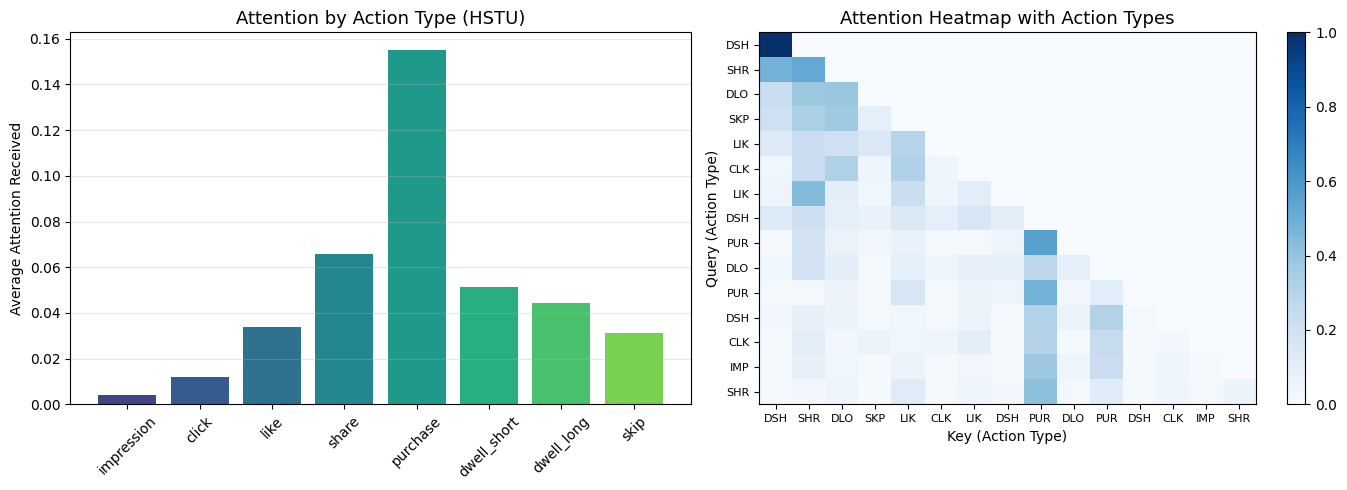

In [11]:
# Analyze how different action types affect attention
hstu.eval()

# Pick a test user
sample_items = test_items[:1, :20]
sample_actions = test_actions[:1, :20]
sample_times = test_times[:1, :20]

with torch.no_grad():
    _, _, attn_weights = hstu(sample_items, sample_actions, sample_times)

# Average attention received by each action type
last_layer_attn = attn_weights[-1][0].mean(dim=0).cpu().numpy()  # Average over heads: (L, L)
actions_np = sample_actions[0].numpy()

# For each action type, compute average attention it receives
action_attention = {}
for action_name, action_id in ACTION_TYPES.items():
    positions = np.where(actions_np == action_id)[0]
    if len(positions) > 0:
        # Average attention received at these positions
        avg_attn = last_layer_attn[:, positions].mean()
        action_attention[action_name] = avg_attn

if action_attention:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Attention by action type
    names = list(action_attention.keys())
    values = [action_attention[n] for n in names]
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))
    axes[0].bar(names, values, color=colors)
    axes[0].set_ylabel('Average Attention Received')
    axes[0].set_title('Attention by Action Type (HSTU)', fontsize=13)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Full attention heatmap with action annotations
    im = axes[1].imshow(last_layer_attn[:15, :15], cmap='Blues', aspect='auto')
    
    # Annotate action types
    action_short = {0: 'IMP', 1: 'CLK', 2: 'LIK', 3: 'SHR',
                     4: 'PUR', 5: 'DSH', 6: 'DLO', 7: 'SKP'}
    labels = [action_short.get(a, '?') for a in actions_np[:15]]
    axes[1].set_xticks(range(15))
    axes[1].set_xticklabels(labels, fontsize=8)
    axes[1].set_yticks(range(15))
    axes[1].set_yticklabels(labels, fontsize=8)
    axes[1].set_xlabel('Key (Action Type)')
    axes[1].set_ylabel('Query (Action Type)')
    axes[1].set_title('Attention Heatmap with Action Types', fontsize=13)
    plt.colorbar(im, ax=axes[1])
    
    plt.tight_layout()
    plt.show()
else:
    print('No diverse actions in sample; try a different test user.')

## Exercises

### 🏋️ Exercise 1: Implement a Simplified HSTU with Action Weighting

Add value-weighted loss where purchases contribute more than clicks.

In [12]:
# TODO: Implement value-weighted HSTU loss
def value_weighted_loss(item_logits, action_logits, target_items, target_actions):
    """
    TODO:
    1. Compute base cross-entropy for item prediction
    2. Weight each position by the action value:
       - Purchase positions get weight 5.0
       - Click positions get weight 1.0
       - Skip positions get weight 0.5
    3. Apply weights to the item loss
    4. Train HSTU with this weighted loss
    5. Compare HR@20 for each action type separately
    """
    pass

# TODO: Train and compare against uniform weighting

### 🏋️ Exercise 2: Add Relative Time Encoding

Replace absolute time encoding with relative time gaps between actions.

In [13]:
# TODO: Implement relative time encoding
class RelativeTimeEncoding(nn.Module):
    """
    TODO:
    1. Compute time gaps: dt[i] = time[i] - time[i-1]
    2. Bucket time gaps into categories:
       - Same session (< 30min)
       - Same day
       - Same week
       - Longer
    3. Embed bucketed time gaps
    4. Add to attention bias (closer actions get higher attention)
    """
    def __init__(self, n_buckets=10, embed_dim=64):
        super().__init__()
        # TODO: Implement
        pass
    
    def forward(self, timestamps):
        # TODO: Implement
        pass

# TODO: Integrate into HSTU and evaluate improvement

### 🏋️ Exercise 3: Multi-Task HSTU with Retrieval and Ranking Heads

Implement separate retrieval and ranking objectives in a single model.

In [14]:
# TODO: Unified retrieval + ranking HSTU
class UnifiedHSTU(nn.Module):
    """
    TODO:
    1. Retrieval head: sampled softmax over all items (next-item prediction)
    2. Ranking head: binary prediction for (user, item) relevance
    3. Combined loss: L = L_retrieval + alpha * L_ranking
    4. At inference:
       - Retrieval: use retrieval head to get top-K candidates
       - Ranking: use ranking head to re-rank candidates
    5. Compare: two-stage pipeline vs unified model
    """
    def __init__(self, n_items, n_actions, embed_dim=64):
        super().__init__()
        # TODO: Implement
        pass

# TODO: Train and demonstrate unified retrieval + ranking

### 🏋️ Exercise 4: Analyze Action Sequence Patterns

Study what action sequences lead to conversions.

In [15]:
# TODO: Action sequence analysis
# 1. Extract all subsequences leading to a 'purchase' action
# 2. Compute transition probabilities between action types
# 3. Visualize the action transition matrix as a heatmap
# 4. Find the most common paths: impression -> click -> ... -> purchase
# 5. Compare HSTU's predicted action probabilities with actual transitions

## Summary

| Model | Key Innovation | Scale | Year |
|-------|---------------|-------|------|
| **HSTU** (Meta) | Actions as tokens, unified retrieval+ranking | 1.5T params | 2024 |
| **ItemSage** (Meta) | Multi-task item embeddings | Production scale | 2024 |
| **GR4Rec** | Generative retrieval with beam search | Research | 2023 |
| **RECFORMER** | Item title tokenization | Research | 2023 |

### The Paradigm Shift

| Aspect | Discriminative (Traditional) | Generative (HSTU) |
|--------|---------------------------|-------------------|
| Architecture | Multi-stage pipeline | Single model |
| Signal | Clicks only (typically) | All actions |
| Training | Stage-specific losses | Unified next-action prediction |
| Serving | Retrieval -> Ranking -> Re-ranking | Single forward pass |
| Cold-start | Separate handling needed | Handled via action patterns |

**Key Takeaways:**
1. HSTU represents the most significant architectural shift in recommendation since deep learning adoption
2. Treating ALL user actions as training signal is strictly better than clicks alone
3. The actions-as-tokens formulation allows a single model to handle retrieval and ranking
4. Action-aware attention learns to weight different types of engagement appropriately
5. The paradigm shift mirrors NLP: from task-specific models to unified generative models